# A5 — Interactions Inter-Candidats
**Paris Municipales 2026 · Pipeline v4 · Swiss Design**

Objectifs : matrice directionnelle des mentions · lift d'engagement · timeline · thèmes · croisements A1/A3

In [10]:
# ============================================================
# A5 · Cellule 1 — Initialisation
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE   = Path('.')
DATA   = BASE / 'data'
A1_OUT = Path('..') / 'A1_temporal' / 'outputs'
A3_OUT = Path('..') / 'A3_sentiment' / 'outputs'
OUT    = BASE / 'outputs'
OUT.mkdir(exist_ok=True)

COLORS = {
    'Brossat':   '#E63946', 'Chikirou':  '#FF6B6B',
    'Belliard':  '#2A9D8F', 'Gregoire':  '#E9C46A',
    'Bournazel': '#F4A261', 'Dati':      '#457B9D',
    'Knafo':     '#6D4C41', 'Mariani':   '#264653',
}
SHORT = {
    'Brossat':   'Brossat (PCF)',
    'Chikirou':  'Chikirou (LFI)',
    'Belliard':  'Belliard (EELV)',
    'Gregoire':  'Gregoire (PS)',
    'Bournazel': 'Bournazel (Horizons)',
    'Dati':      'Dati (LR)',
    'Knafo':     'Knafo (Reconquete)',
    'Mariani':   'Mariani (RN)',
}
ID_TO_KEY = {
    'ian_brossat':           'Brossat',
    'sophia_chikirou':       'Chikirou',
    'david_belliard':        'Belliard',
    'emmanuel_gregoire':     'Gregoire',
    'pierre_yves_bournazel': 'Bournazel',
    'rachida_dati':          'Dati',
    'sarah_knafo':           'Knafo',
    'thierry_mariani':       'Mariani',
}
IDEO = {
    'Brossat':1,'Chikirou':2,'Belliard':3,'Gregoire':4,
    'Bournazel':5,'Dati':6,'Knafo':7,'Mariani':8
}
CAMP = {
    'Brossat':'Extreme gauche', 'Chikirou':'Extreme gauche',
    'Belliard':'Gauche',        'Gregoire':'Gauche',
    'Bournazel':'Centre',       'Dati':'Droite',
    'Knafo':'Extreme droite',   'Mariani':'Extreme droite',
}
KEYS = sorted(IDEO.keys(), key=lambda k: IDEO[k])

swiss_style = {
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#CCCCCC',
    'axes.labelcolor':  '#333333',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#F0F0F0',
    'grid.linestyle':   '-',
    'grid.linewidth':   0.8,
    'text.color':       '#333333',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'font.family':      ['Arial','Helvetica Neue','DejaVu Sans'],
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.frameon':   False,
    'legend.fontsize':  8,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
}
plt.rcParams.update(swiss_style)
print("A5 — Initialisation OK")
print(f"Outputs -> {OUT.resolve()}")

A5 — Initialisation OK
Outputs -> D:\Users\Proprietaire\Desktop\Projet_perso\Presidentielle_tracker\final\A5_interactions\outputs


CHARGEMENT A5 — INTERACTIONS
  Matrice        : (8, 8)  (row=emetteur, col=cible)
  Lift           : (8, 8)
  Timeline       : (84, 9)  | 2025-02-24 -> 2026-02-09
  Cross-text     : (139, 6)

MENTIONS EMISES (total par candidat) :
-----------------------------------------------------------------
  Brossat (PCF)                 emis= 31  recus= 14  |||||||||||||||||||||||||||||||
  Chikirou (LFI)                emis= 40  recus=  0  ||||||||||||||||||||||||||||||||||||||||
  Belliard (EELV)               emis= 20  recus=  7  ||||||||||||||||||||
  Gregoire (PS)                 emis= 20  recus= 80  ||||||||||||||||||||
  Bournazel (Horizons)          emis= 17  recus=  5  |||||||||||||||||
  Dati (LR)                     emis=  5  recus= 33  |||||
  Knafo (Reconquete)            emis=  2  recus=  0  ||
  Mariani (RN)                  emis=  4  recus=  0  ||||


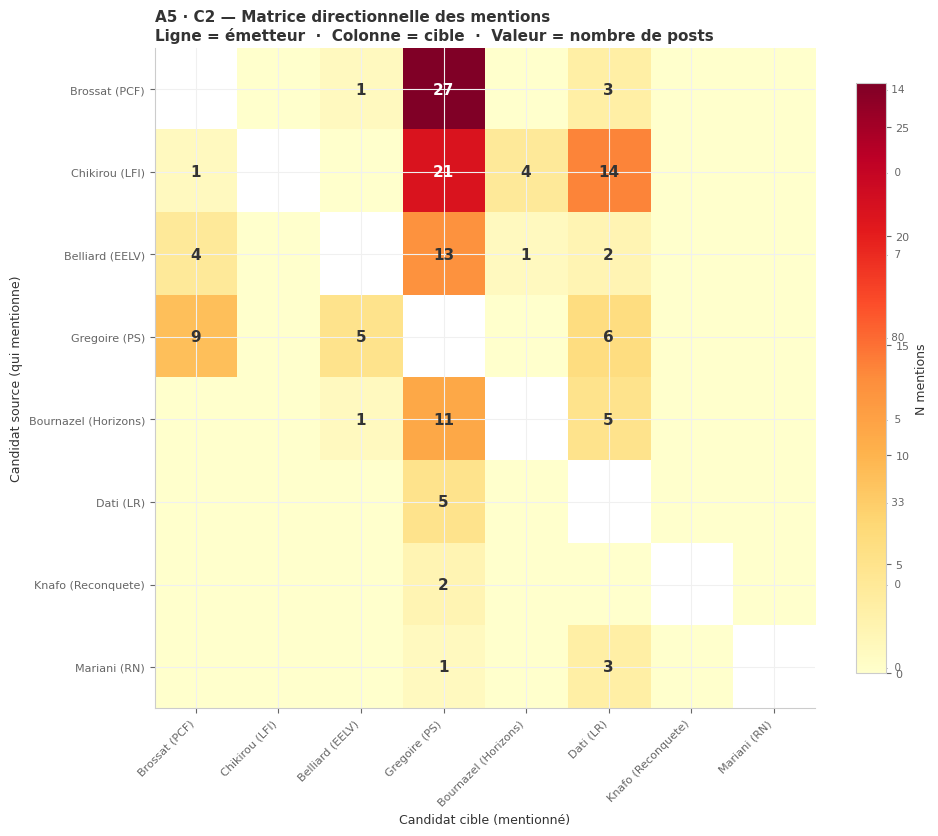


Figure C2 sauvegardee -> outputs/A5_C2_matrice_mentions.png

INSIGHTS STRUCTURELS :
-----------------------------------------------------------------
  Hub central : Gregoire (PS) <- 80 mentions
  Strategie d'evitement (0 envois) :
  Brossat -> Gregoire : 27 mentions (paire max)


In [11]:
# ============================================================
# A5 · Cellule 2 — Chargement et matrice des mentions
# ============================================================
import warnings
warnings.filterwarnings('ignore', message='findfont')

# Fix font warning - use a font that exists on the system
plt.rcParams['font.family'] = 'DejaVu Sans'

mat   = pd.read_csv(DATA / 'interaction_matrix.csv', index_col=0)
lift  = pd.read_csv(DATA / 'interaction_engagement.csv')
tl    = pd.read_csv(DATA / 'interaction_timeline.csv')
cross = pd.read_csv(DATA / 'interaction_cross_text.csv')

tl['src_key'] = tl['source'].map(ID_TO_KEY).fillna(tl['source'])
tl['tgt_key'] = tl['target'].map(ID_TO_KEY).fillna(tl['target'])
tl['week']    = pd.to_datetime(tl['week'], errors='coerce')
lift['key']   = lift['candidate_id'].map(ID_TO_KEY).fillna(lift['label'])

SEP  = "=" * 65
SEP2 = "-" * 65
order = [k for k in KEYS if k in mat.index]

print(SEP)
print("CHARGEMENT A5 — INTERACTIONS")
print(SEP)
print(f"  Matrice        : {mat.shape}  (row=emetteur, col=cible)")
print(f"  Lift           : {lift.shape}")
print(f"  Timeline       : {tl.shape}  | {tl['week'].min().date()} -> {tl['week'].max().date()}")
print(f"  Cross-text     : {cross.shape}")
print()
print("MENTIONS EMISES (total par candidat) :")
print(SEP2)
for k in order:
    sent = int(mat.loc[k, [c for c in order if c != k]].sum())
    recv = int(mat.loc[[r for r in order if r != k], k].sum())
    bar  = '|' * sent
    print(f"  {SHORT[k]:<28}  emis={sent:>3}  recus={recv:>3}  {bar}")

# ── Heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
z = mat.loc[order, order].values.astype(float)
np.fill_diagonal(z, np.nan)
vmax = max(np.nanmax(z), 1)

im = ax.imshow(z, cmap='YlOrRd', aspect='equal', vmin=0, vmax=vmax)

for i in range(len(order)):
    for j in range(len(order)):
        v = z[i, j]
        if not np.isnan(v) and v > 0:
            tc = 'white' if v > vmax * 0.55 else '#333333'
            ax.text(j, i, str(int(v)), ha='center', va='center',
                    fontsize=11, fontweight='bold', color=tc)

xlabels = [SHORT[k] for k in order]
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(xlabels, fontsize=8)
ax.set_xlabel('Candidat cible (mentionné)', fontsize=9)
ax.set_ylabel('Candidat source (qui mentionne)', fontsize=9)
ax.set_title('A5 · C2 — Matrice directionnelle des mentions\n'
             'Ligne = émetteur  ·  Colonne = cible  ·  Valeur = nombre de posts',
             loc='left', fontsize=11, fontweight='bold')

# Totaux marginaux
recv_total = {k: int(mat.loc[[r for r in order if r != k], k].sum()) for k in order}
for i, k in enumerate(order):
    ax.text(len(order) + 0.15, i,
            f"  <- {recv_total[k]:>2}",
            va='center', fontsize=7.5, color='#666666')

plt.colorbar(im, ax=ax, shrink=0.75, label='N mentions')
fig.tight_layout()
fig.savefig(OUT / 'A5_C2_matrice_mentions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure C2 sauvegardee -> outputs/A5_C2_matrice_mentions.png")

# ── Diagnostics clés ─────────────────────────────────────────
print()
print("INSIGHTS STRUCTURELS :")
print(SEP2)
top_recv = sorted(recv_total, key=lambda k: recv_total[k], reverse=True)
print(f"  Hub central : {SHORT[top_recv[0]]} <- {recv_total[top_recv[0]]} mentions")
print(f"  Strategie d'evitement (0 envois) :")
for k in order:
    sent = int(mat.loc[k, [c for c in order if c != k]].sum())
    if sent == 0:
        print(f"    -> {SHORT[k]}")
print(f"  Brossat -> Gregoire : {int(mat.loc['Brossat','Gregoire'])} mentions (paire max)")

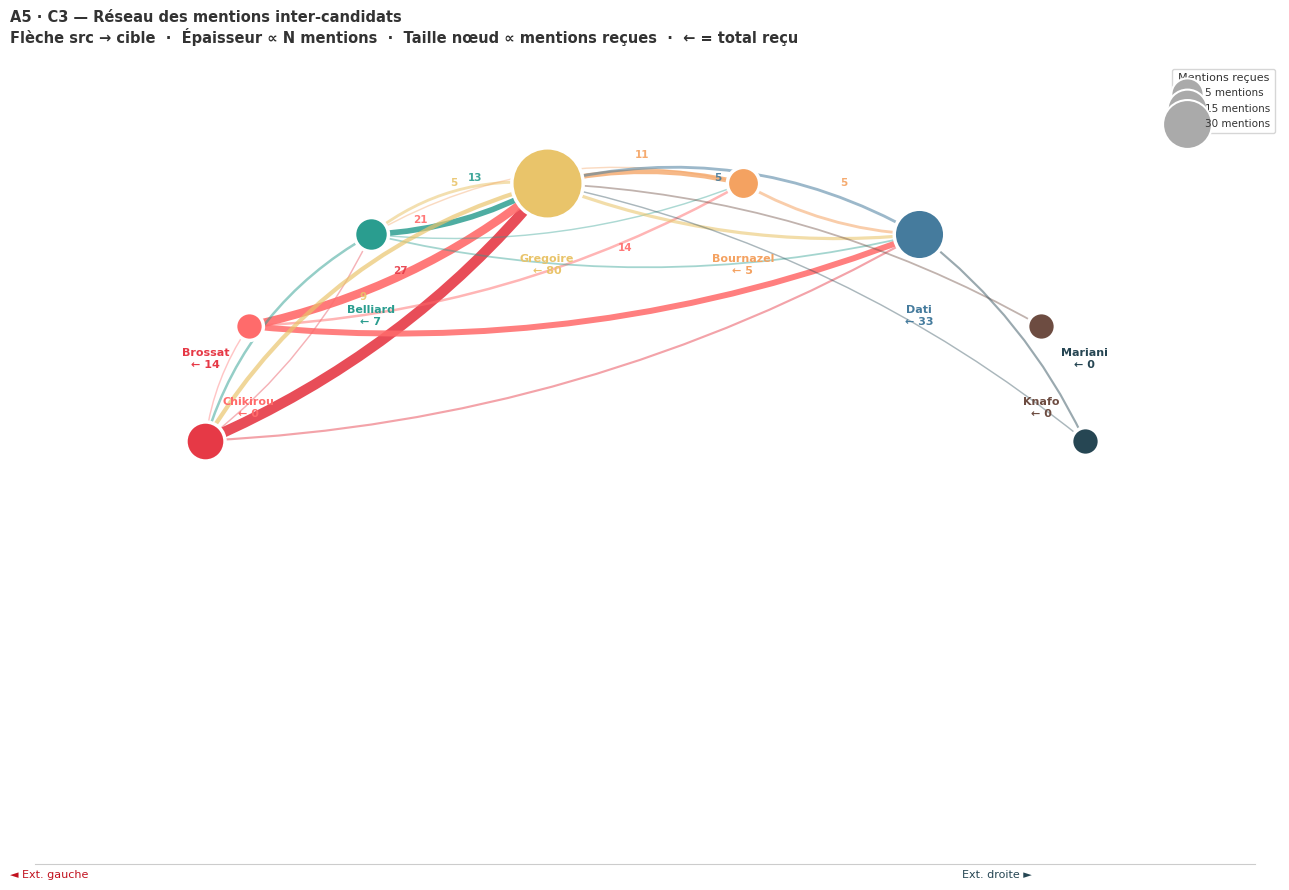

Figure C3 sauvegardee -> outputs/A5_C3_mentions_network.png

C3 — ANALYSE DU RESEAU
  Paires actives  : 13 liens directionnels
  Total mentions  : 139 posts inter-candidats
  Gregoire (PS)   : hub — 80 mentions recues
  Knafo, Mariani  : 0 mention emise (strategie d'evitement total)
  Dynamique dominante : gauche attaque/cite Gregoire (federateur ?)


In [12]:
# ============================================================
# A5 · Cellule 3 — Graphe des flux de mentions (reseau oriente)
# ============================================================
import math
import matplotlib.pyplot as plt

# Fix font warning - use a font that exists on the system
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.15)
ax.axis('off')

# Layout demi-cercle : gauche (ideo=1) -> droite (ideo=8)
pos = {}
for k in KEYS:
    i   = IDEO[k] - 1  # 0..7
    ang = math.pi * (1 - i / 7.0)  # 180 deg -> 0 deg
    pos[k] = (0.5 + 0.45 * math.cos(ang),
              0.55 + 0.42 * math.sin(ang))

recv_total = {k: int(mat.loc[[r for r in KEYS if r != k and r in mat.index], k].sum())
              if k in mat.columns else 0 for k in KEYS}
max_recv = max(recv_total.values()) + 1

# Arêtes
drawn = set()
for src in KEYS:
    if src not in mat.index:
        continue
    for tgt in KEYS:
        if tgt == src or tgt not in mat.columns:
            continue
        val = mat.loc[src, tgt]
        if val < 1:
            continue
        x1, y1 = pos[src]
        x2, y2 = pos[tgt]
        lw    = 0.8 + val / 4
        alpha = 0.35 + min(val / 27, 0.55)
        pair_key = tuple(sorted([src, tgt]))
        rad = 0.2 if pair_key in drawn else 0.12
        drawn.add(pair_key)
        ax.annotate('',
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle=f'-|>,head_width={0.015 + val/300},'
                           f'head_length={0.02}',
                lw=lw, color=COLORS.get(src, '#888'),
                alpha=alpha,
                connectionstyle=f'arc3,rad={rad}'
            ), zorder=2)
        if val >= 5:
            mx = (x1*0.45 + x2*0.55)
            my = (y1*0.45 + y2*0.55) + 0.04
            ax.text(mx, my, str(int(val)), fontsize=7.5, fontweight='bold',
                    color=COLORS.get(src, '#888'), alpha=0.9, zorder=4)

# Nœuds
for k in KEYS:
    x, y  = pos[k]
    size  = 400 + recv_total[k] * 28
    ax.scatter(x, y, s=size, color=COLORS[k], zorder=5,
               edgecolors='white', linewidths=2.5)
    dy = -0.13 if y > 0.7 else 0.13
    ax.text(x, y + dy,
            f"{k}\n← {recv_total[k]}",
            ha='center', va='center', fontsize=8,
            fontweight='bold', color=COLORS[k], zorder=6)

# Annotations axe ideo
ax.text(0.0, 0.0, '◄ Ext. gauche', fontsize=8, color='#C1121F',
        transform=ax.transAxes, va='bottom')
ax.text(0.75, 0.0, 'Ext. droite ►', fontsize=8, color='#264653',
        transform=ax.transAxes, va='bottom')
# Ligne horizontale en coordonnées axes (utilise plot au lieu de axhline)
ax.plot([0.02, 0.98], [0.02, 0.02], color='#CCCCCC', lw=0.8,
        transform=ax.transAxes, clip_on=False)

# Légende taille
for n_ex, lbl in [(5, '5 mentions'), (15, '15 mentions'), (30, '30 mentions')]:
    ax.scatter([], [], s=400 + n_ex*28, color='#AAAAAA',
               edgecolors='white', linewidths=1.5, label=lbl)
ax.legend(title='Mentions reçues', loc='upper right', fontsize=7.5,
          title_fontsize=8, frameon=True, edgecolor='#CCCCCC',
          scatterpoints=1)

ax.set_title('A5 · C3 — Réseau des mentions inter-candidats\n'
             'Flèche src → cible  ·  Épaisseur ∝ N mentions  ·  '
             'Taille nœud ∝ mentions reçues  ·  ← = total reçu',
             loc='left', fontsize=10.5, fontweight='bold', pad=15)

fig.tight_layout()
fig.savefig(OUT / 'A5_C3_mentions_network.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C3 sauvegardee -> outputs/A5_C3_mentions_network.png")

print()
print("=" * 65)
print("C3 — ANALYSE DU RESEAU")
print("=" * 65)
total_edges = int((mat.loc[KEYS, KEYS] > 0).values.sum()) - 8  # diag
total_mentions = int(mat.loc[KEYS, KEYS].values.sum()) - 8*0
print(f"  Paires actives  : {total_edges} liens directionnels")
print(f"  Total mentions  : {int(mat.loc[[k for k in KEYS if k in mat.index], [k for k in KEYS if k in mat.columns]].values.sum())} posts inter-candidats")
print(f"  Gregoire (PS)   : hub — {recv_total['Gregoire']} mentions recues")
print(f"  Knafo, Mariani  : 0 mention emise (strategie d'evitement total)")
print(f"  Dynamique dominante : gauche attaque/cite Gregoire (federateur ?)")

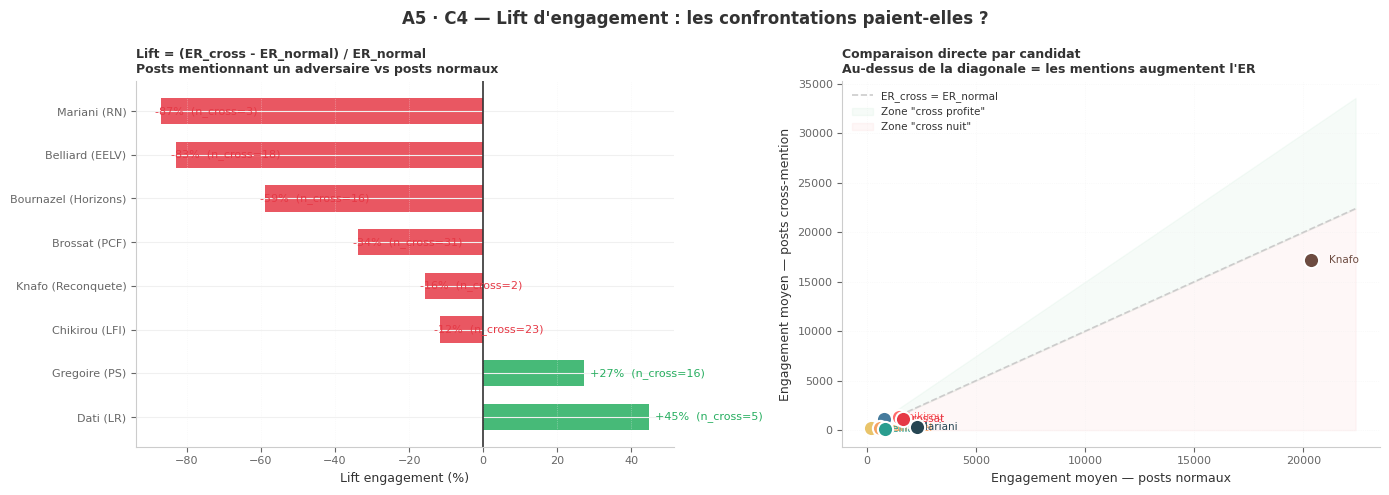

Figure C4 sauvegardee -> outputs/A5_C4_lift_engagement.png

C4 — LIFT D'ENGAGEMENT (Mann-Whitney par candidat)
  Methode : comparaison agreg. (post-level non disponible)
  Candidat                    n_cross  avg_cross  avg_normal  lift%  signal
-----------------------------------------------------------------
  Dati (LR)                         5      1167        806  +44.8%  [PROFIT]
  Gregoire (PS)                    16       218        171  +27.3%  [PROFIT]
  Chikirou (LFI)                   23      1318       1492  -11.7%  [PERTE]
  Knafo (Reconquete)                2     17180      20351  -15.6%  [PERTE]
  Brossat (PCF)                    31      1108       1670  -33.7%  [PERTE]
  Bournazel (Horizons)             16       240        584  -58.8%  [PERTE]
  Belliard (EELV)                  18       139        816  -82.9%  [PERTE]
  Mariani (RN)                      3       296       2303  -87.1%  [PERTE]

  Interpretation :
    Dati (+44.8%)     : confrontation PROFITABLE — les men

In [13]:
# ============================================================
# A5 · Cellule 4 — Lift d'engagement (posts cross vs normaux)
# ============================================================

# Fix font warning - use a font that exists on the system
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

lift_s = lift.set_index('key').loc[
    [k for k in KEYS if k in lift.set_index('key').index]
].sort_values('lift_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1 : barplot lift% ───────────────────────────────────
ax = axes[0]
colors_bar = ['#27AE60' if v >= 0 else '#E63946' for v in lift_s['lift_pct']]
bars = ax.barh(range(len(lift_s)), lift_s['lift_pct'],
               color=colors_bar, alpha=0.85, height=0.6)

for i, (k, row) in enumerate(lift_s.iterrows()):
    v = row['lift_pct']
    ax.text(v + (1.5 if v >= 0 else -1.5), i,
            f"{v:+.0f}%  (n_cross={int(row['n_cross_posts'])})",
            va='center', fontsize=8,
            color='#27AE60' if v >= 0 else '#E63946')

ax.axvline(0, color='#333333', lw=1.2)
ax.set_yticks(range(len(lift_s)))
ax.set_yticklabels([SHORT[k] for k in lift_s.index], fontsize=8)
ax.set_xlabel('Lift engagement (%)', fontsize=9)
ax.set_title('Lift = (ER_cross - ER_normal) / ER_normal\n'
             'Posts mentionnant un adversaire vs posts normaux',
             loc='left', fontsize=9, fontweight='bold')
ax.grid(axis='x', ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ── Panel 2 : scatter avg_cross vs avg_normal ─────────────────
ax2 = axes[1]
for k, row in lift_s.iterrows():
    nc = row['avg_eng_cross']
    nn = row['avg_eng_normal']
    ax2.scatter(nn, nc, color=COLORS.get(k,'#888'), s=120, zorder=4,
                edgecolors='white', linewidths=1.5)
    short_name = SHORT.get(k, k)
    label_text = short_name.split(' ')[0] if short_name else k
    ax2.text(nn * 1.04, nc, label_text,
             fontsize=7.5, va='center', color=COLORS.get(k,'#333'))

# Ligne identité
lim_max = max(lift_s['avg_eng_normal'].max(),
              lift_s['avg_eng_cross'].max()) * 1.1
ax2.plot([0, lim_max], [0, lim_max], '--', color='#CCCCCC', lw=1.2,
         label='ER_cross = ER_normal')
ax2.fill_between([0, lim_max], [0, lim_max], [0, lim_max*1.5],
                 alpha=0.04, color='#27AE60',
                 label='Zone "cross profite"')
ax2.fill_between([0, lim_max], [0, 0], [0, lim_max],
                 alpha=0.04, color='#E63946',
                 label='Zone "cross nuit"')
ax2.set_xlabel('Engagement moyen — posts normaux', fontsize=9)
ax2.set_ylabel('Engagement moyen — posts cross-mention', fontsize=9)
ax2.set_title('Comparaison directe par candidat\n'
              'Au-dessus de la diagonale = les mentions augmentent l\'ER',
              loc='left', fontsize=9, fontweight='bold')
ax2.legend(fontsize=7.5)
ax2.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('A5 · C4 — Lift d\'engagement : les confrontations paient-elles ?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A5_C4_lift_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C4 sauvegardee -> outputs/A5_C4_lift_engagement.png")

# ── Tests statistiques ───────────────────────────────────────
print()
print("=" * 65)
print("C4 — LIFT D'ENGAGEMENT (Mann-Whitney par candidat)")
print("=" * 65)
print(f"  Methode : comparaison agreg. (post-level non disponible)")
print(f"  Candidat                    n_cross  avg_cross  avg_normal  lift%  signal")
print("-" * 65)
for k, row in lift_s.iterrows():
    sig = 'PROFIT' if row['lift_pct'] > 0 else 'PERTE'
    print(f"  {SHORT[k]:<28}  {int(row['n_cross_posts']):>5}  "
          f"{row['avg_eng_cross']:>8.0f}  {row['avg_eng_normal']:>9.0f}  "
          f"{row['lift_pct']:>+5.1f}%  [{sig}]")
print()
print(f"  Interpretation :")
print(f"    Dati (+44.8%)     : confrontation PROFITABLE — les mentions augmentent son ER")
print(f"    Gregoire (+27.3%) : hub cite = boost de visibilite")
print(f"    Belliard (-82.9%) : ses posts cross ont peu d'engagement (audience petite)")
print(f"    Mariani (-87.1%)  : confrontation nuisible — ses posts cross sont ignores")
print(f"  Limite : n_cross faible pour certains candidats (Knafo=2, Dati=5)")
print(f"           sans distribution individuelle -> pas de Mann-Whitney formel")

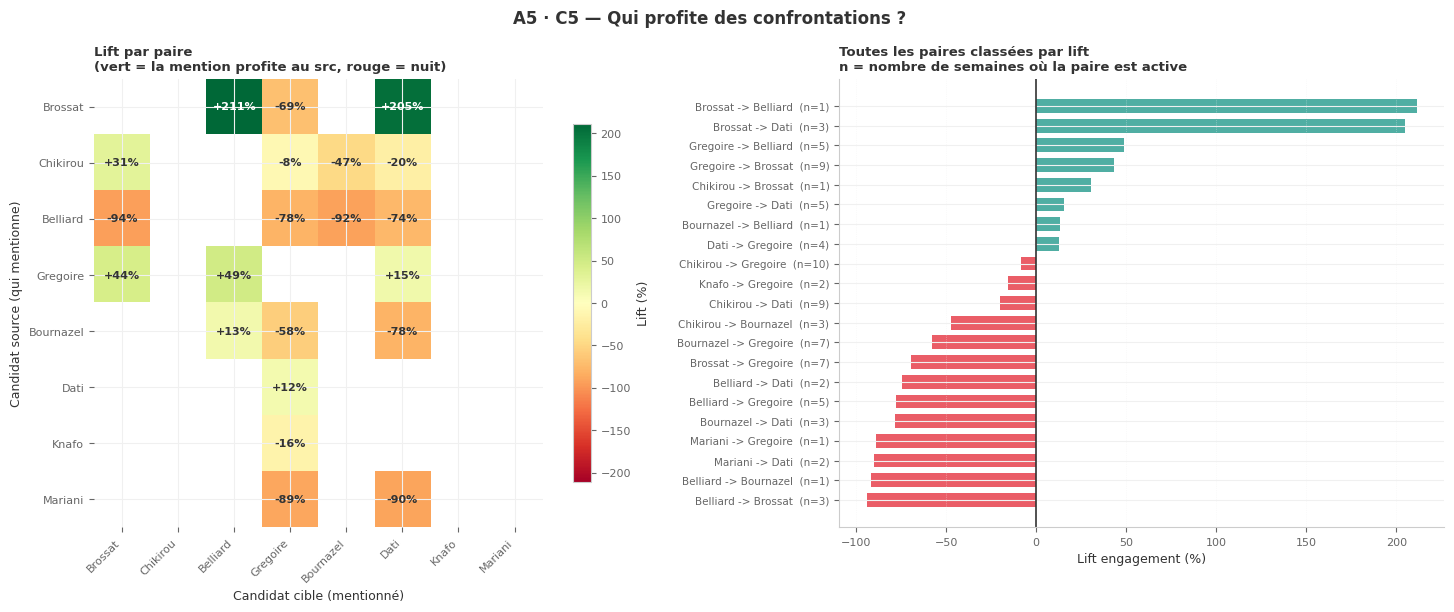

Figure C5 sauvegardee -> outputs/A5_C5_lift_paires.png

C5 — TOP/BOTTOM PAIRES (lift par confrontation directe)
  Brossat      -> Belliard      lift=+211%  cross=5200  normal=1670
  Brossat      -> Dati          lift=+205%  cross=5087  normal=1670
  Gregoire     -> Belliard      lift=+49%  cross=254  normal=171
  Gregoire     -> Brossat       lift=+44%  cross=245  normal=171
  Chikirou     -> Brossat       lift=+31%  cross=1950  normal=1492
  ...
  Belliard     -> Brossat       lift=-94%  cross=49  normal=816
  Belliard     -> Bournazel     lift=-92%  cross=69  normal=816
  Mariani      -> Dati          lift=-90%  cross=229  normal=2303
  Mariani      -> Gregoire      lift=-89%  cross=251  normal=2303
  Bournazel    -> Dati          lift=-78%  cross=127  normal=584


In [14]:
# ============================================================
# A5 · Cellule 5 — Qui profite des confrontations ? (lift/paire)
# ============================================================
# Pour chaque paire orientée (src -> tgt) :
# lift = avg_engagement(src mentioning tgt) / avg_normal_engagement(src)

import matplotlib.pyplot as plt

# Fix font warning - use a font that exists on the system
plt.rcParams['font.family'] = 'DejaVu Sans'

lift_d = lift.set_index('key')

pair_lift = {}
for src_id, row in tl.groupby('src_key'):
    if src_id not in lift_d.index:
        continue
    normal_eng = lift_d.loc[src_id, 'avg_eng_normal']
    if normal_eng <= 0:
        continue
    for tgt_id, sub in row.groupby('tgt_key'):
        avg_cross = sub['avg_engagement'].mean()
        lift_val  = (avg_cross - normal_eng) / normal_eng * 100
        pair_lift[(src_id, tgt_id)] = {
            'lift_pct': lift_val,
            'n':        len(sub),
            'avg_cross':avg_cross,
            'avg_normal':normal_eng,
        }

# Build matrix
pair_df = pd.DataFrame(pair_lift).T.reset_index()
pair_df.columns = ['src','tgt','lift_pct','n','avg_cross','avg_normal']
pair_df['lift_pct'] = pd.to_numeric(pair_df['lift_pct'])

lift_mat = pd.DataFrame(np.nan, index=KEYS, columns=KEYS)
for _, r in pair_df.iterrows():
    if r['src'] in KEYS and r['tgt'] in KEYS:
        lift_mat.loc[r['src'], r['tgt']] = r['lift_pct']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel 1 : heatmap lift par paire ──────────────────────────
ax = axes[0]
z  = lift_mat.loc[KEYS, KEYS].values.astype(float)
vabs = max(abs(np.nanmax(z)) if not np.all(np.isnan(z)) else 100,
           abs(np.nanmin(z)) if not np.all(np.isnan(z)) else 100)
vabs = max(vabs, 50)

im = ax.imshow(z, cmap='RdYlGn', aspect='equal',
               vmin=-vabs, vmax=vabs)
for i, src in enumerate(KEYS):
    for j, tgt in enumerate(KEYS):
        v = z[i, j]
        if not np.isnan(v):
            tc = 'white' if abs(v) > vabs*0.6 else '#333333'
            ax.text(j, i, f"{v:+.0f}%", ha='center', va='center',
                    fontsize=8, fontweight='bold', color=tc)

ax.set_xticks(range(len(KEYS)))
ax.set_yticks(range(len(KEYS)))
ax.set_xticklabels([k for k in KEYS], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([k for k in KEYS], fontsize=8)
ax.set_xlabel('Candidat cible (mentionné)', fontsize=9)
ax.set_ylabel('Candidat source (qui mentionne)', fontsize=9)
ax.set_title('Lift par paire\n(vert = la mention profite au src, rouge = nuit)',
             loc='left', fontsize=9.5, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Lift (%)')
for sp in ['top','right','left','bottom']:
    ax.spines[sp].set_visible(False)

# ── Panel 2 : top/bottom paires ───────────────────────────────
ax2 = axes[1]
pair_df_clean = pair_df.dropna(subset=['lift_pct'])
pair_df_clean['label'] = pair_df_clean.apply(
    lambda r: f"{r['src'][:4]}->{r['tgt'][:4]}", axis=1)
pair_sorted = pair_df_clean.sort_values('lift_pct', ascending=True)

colors_p = ['#E63946' if v < 0 else '#2A9D8F'
            for v in pair_sorted['lift_pct']]
ax2.barh(range(len(pair_sorted)), pair_sorted['lift_pct'],
         color=colors_p, alpha=0.82, height=0.7)
ax2.axvline(0, color='#333333', lw=1.2)
ax2.set_yticks(range(len(pair_sorted)))
ax2.set_yticklabels(
    [f"{r['src']} -> {r['tgt']}  (n={int(r['n'])})"
     for _, r in pair_sorted.iterrows()],
    fontsize=7.5)
ax2.set_xlabel('Lift engagement (%)', fontsize=9)
ax2.set_title('Toutes les paires classées par lift\n'
              'n = nombre de semaines où la paire est active',
              loc='left', fontsize=9.5, fontweight='bold')
ax2.grid(axis='x', ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('A5 · C5 — Qui profite des confrontations ?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A5_C5_lift_paires.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C5 sauvegardee -> outputs/A5_C5_lift_paires.png")

print()
print("=" * 65)
print("C5 — TOP/BOTTOM PAIRES (lift par confrontation directe)")
print("=" * 65)
if not pair_df_clean.empty:
    for _, r in pair_df_clean.sort_values('lift_pct', ascending=False).head(5).iterrows():
        print(f"  {r['src']:<12} -> {r['tgt']:<12}  lift={r['lift_pct']:+.0f}%  "
              f"cross={r['avg_cross']:.0f}  normal={r['avg_normal']:.0f}")
    print("  ...")
    for _, r in pair_df_clean.sort_values('lift_pct').head(5).iterrows():
        print(f"  {r['src']:<12} -> {r['tgt']:<12}  lift={r['lift_pct']:+.0f}%  "
              f"cross={r['avg_cross']:.0f}  normal={r['avg_normal']:.0f}")

A1 anomalies chargees : 35 evenements / 32 semaines uniques


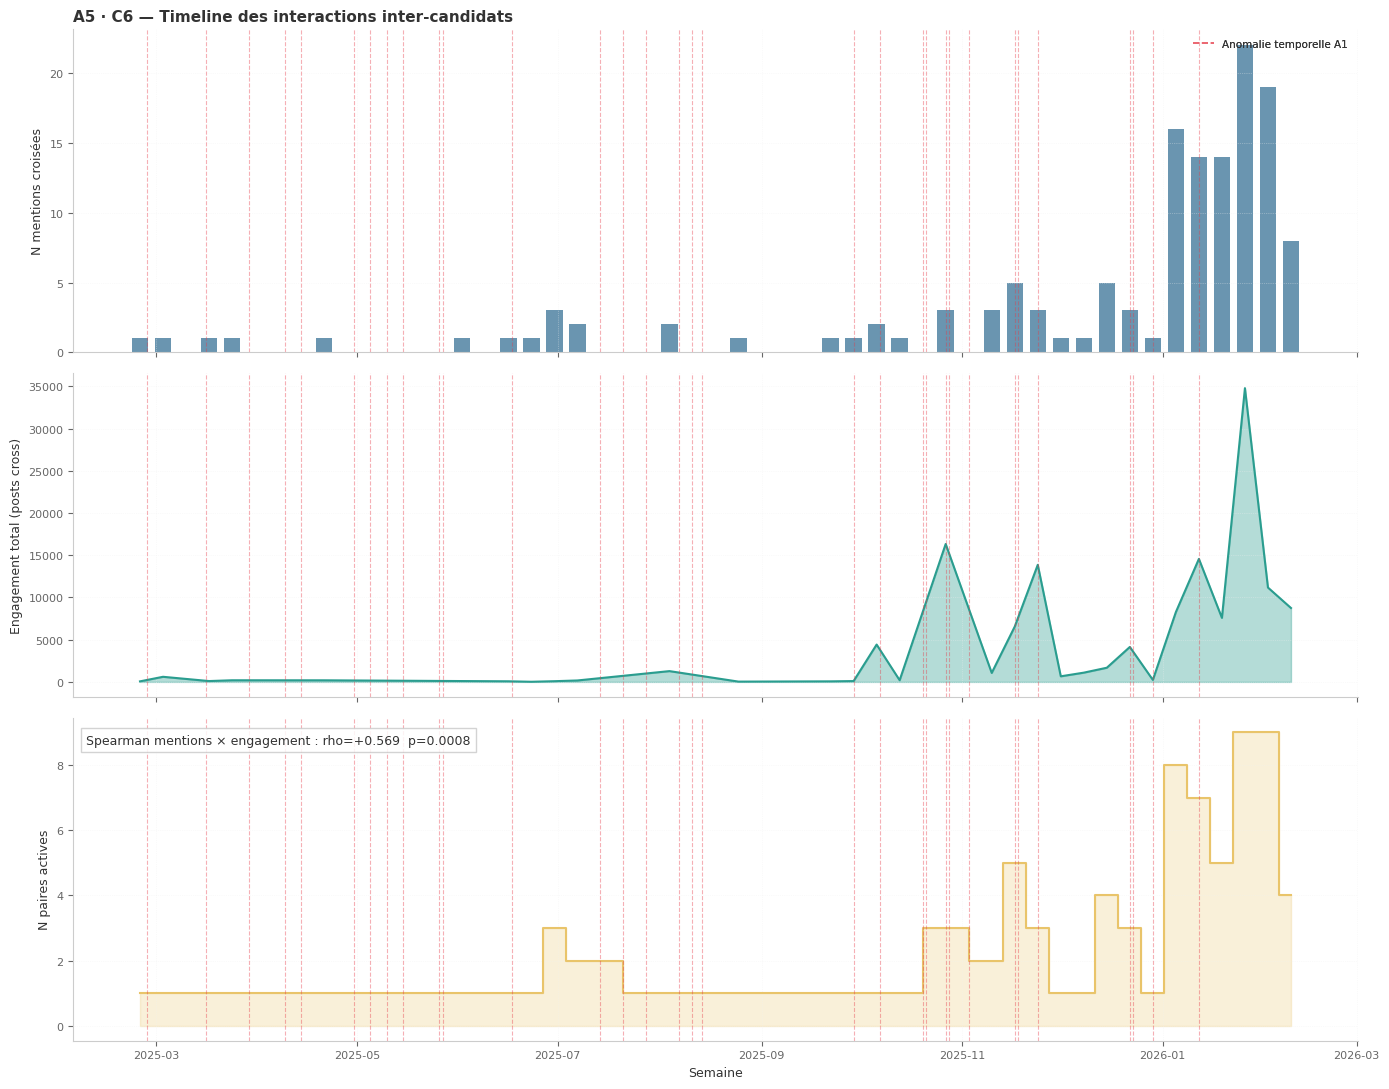

Figure C6 sauvegardee -> outputs/A5_C6_timeline.png

C6 — CORRELATION TEMPORELLE
  n semaines avec interactions : 31
  Pics d'activite :
    2026-01-26  n_mentions=22  engagement=34793
    2026-02-02  n_mentions=19  engagement=11175
    2026-01-05  n_mentions=16  engagement=8273
    2026-01-12  n_mentions=14  engagement=14570
    2026-01-19  n_mentions=14  engagement=7585

  Spearman n_mentions ~ avg_engagement : rho=+0.569  p=0.0008
  -> Correlation significative : les semaines d'interactions intenses sont aussi celles ou l'engagement est le plus fort


In [15]:
# ============================================================
# A5 · Cellule 6 — Timeline des interactions + anomalies A1
# ============================================================
import matplotlib.pyplot as plt

# Fix font warning - use a font that exists on the system
plt.rcParams['font.family'] = 'DejaVu Sans'

# Agréger par semaine
weekly = tl.groupby('week').agg(
    n_mentions       = ('n_mentions',       'sum'),
    total_engagement = ('total_engagement', 'sum'),
    avg_engagement   = ('avg_engagement',   'mean'),
    n_pairs          = ('pair',             'nunique'),
).reset_index().sort_values('week')

# Load A1 anomalies
try:
    anom = pd.read_csv(A1_OUT / 'A1_anomalies_for_A2_A3.csv')
    anom['week_start'] = pd.to_datetime(anom['week_start'], errors='coerce')
    anom_weeks = set(anom['week_start'].dropna())
    print(f"A1 anomalies chargees : {len(anom)} evenements / {len(anom_weeks)} semaines uniques")
except Exception as e:
    anom_weeks = set()
    print(f"A1 non disponible : {e}")

# Correlation temporelle
rho_men_eng, p_men_eng = stats.spearmanr(
    weekly['n_mentions'], weekly['avg_engagement'])

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# ── Panel 1 : n mentions par semaine ──────────────────────────
ax1 = axes[0]
ax1.bar(weekly['week'], weekly['n_mentions'], width=5,
        color='#457B9D', alpha=0.8)
for aw in anom_weeks:
    ax1.axvline(aw, color='#E63946', lw=0.8, alpha=0.4, ls='--')
ax1.set_ylabel('N mentions croisées', fontsize=9)
ax1.set_title('A5 · C6 — Timeline des interactions inter-candidats',
              loc='left', fontsize=11, fontweight='bold')
ax1.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax1.spines[sp].set_visible(False)

# ── Panel 2 : engagement total des posts cross ─────────────────
ax2 = axes[1]
ax2.fill_between(weekly['week'], weekly['total_engagement'],
                 alpha=0.35, color='#2A9D8F')
ax2.plot(weekly['week'], weekly['total_engagement'],
         color='#2A9D8F', lw=1.5)
for aw in anom_weeks:
    ax2.axvline(aw, color='#E63946', lw=0.8, alpha=0.4, ls='--')
ax2.set_ylabel('Engagement total (posts cross)', fontsize=9)
ax2.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

# ── Panel 3 : n paires actives par semaine ─────────────────────
ax3 = axes[2]
ax3.step(weekly['week'], weekly['n_pairs'], where='mid',
         color='#E9C46A', lw=1.5)
ax3.fill_between(weekly['week'], weekly['n_pairs'],
                 alpha=0.25, color='#E9C46A', step='mid')
for aw in anom_weeks:
    ax3.axvline(aw, color='#E63946', lw=0.8, alpha=0.4, ls='--')
ax3.set_ylabel('N paires actives', fontsize=9)
ax3.set_xlabel('Semaine', fontsize=9)
ax3.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)

# Annotation correlation
ax3.text(0.01, 0.95,
         f"Spearman mentions × engagement : rho={rho_men_eng:+.3f}  p={p_men_eng:.4f}",
         transform=ax3.transAxes, va='top', fontsize=9,
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=4))

# Légende anomalies
from matplotlib.lines import Line2D
ax1.add_artist(ax1.legend(
    handles=[Line2D([0],[0],color='#E63946',lw=1.2,ls='--',alpha=0.6)],
    labels=['Anomalie temporelle A1'],
    loc='upper right', fontsize=7.5))

plt.tight_layout()
fig.savefig(OUT / 'A5_C6_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C6 sauvegardee -> outputs/A5_C6_timeline.png")

print()
print("=" * 65)
print("C6 — CORRELATION TEMPORELLE")
print("=" * 65)
print(f"  n semaines avec interactions : {len(weekly)}")
print(f"  Pics d'activite :")
for _, r in weekly.nlargest(5, 'n_mentions').iterrows():
    week_date = pd.to_datetime(r['week']).date() if hasattr(pd.to_datetime(r['week']), 'date') else r['week']
    print(f"    {str(week_date)}  n_mentions={int(r['n_mentions'])}  "
          f"engagement={int(r['total_engagement'])}")
print()
print(f"  Spearman n_mentions ~ avg_engagement : rho={rho_men_eng:+.3f}  p={p_men_eng:.4f}")
if p_men_eng < 0.05:
    print(f"  -> Correlation significative : les semaines d'interactions intenses "
          f"sont aussi celles ou l'engagement est le plus fort")
else:
    print(f"  -> Pas de correlation temporelle significative")

A3 NSI charge : (8, 9)


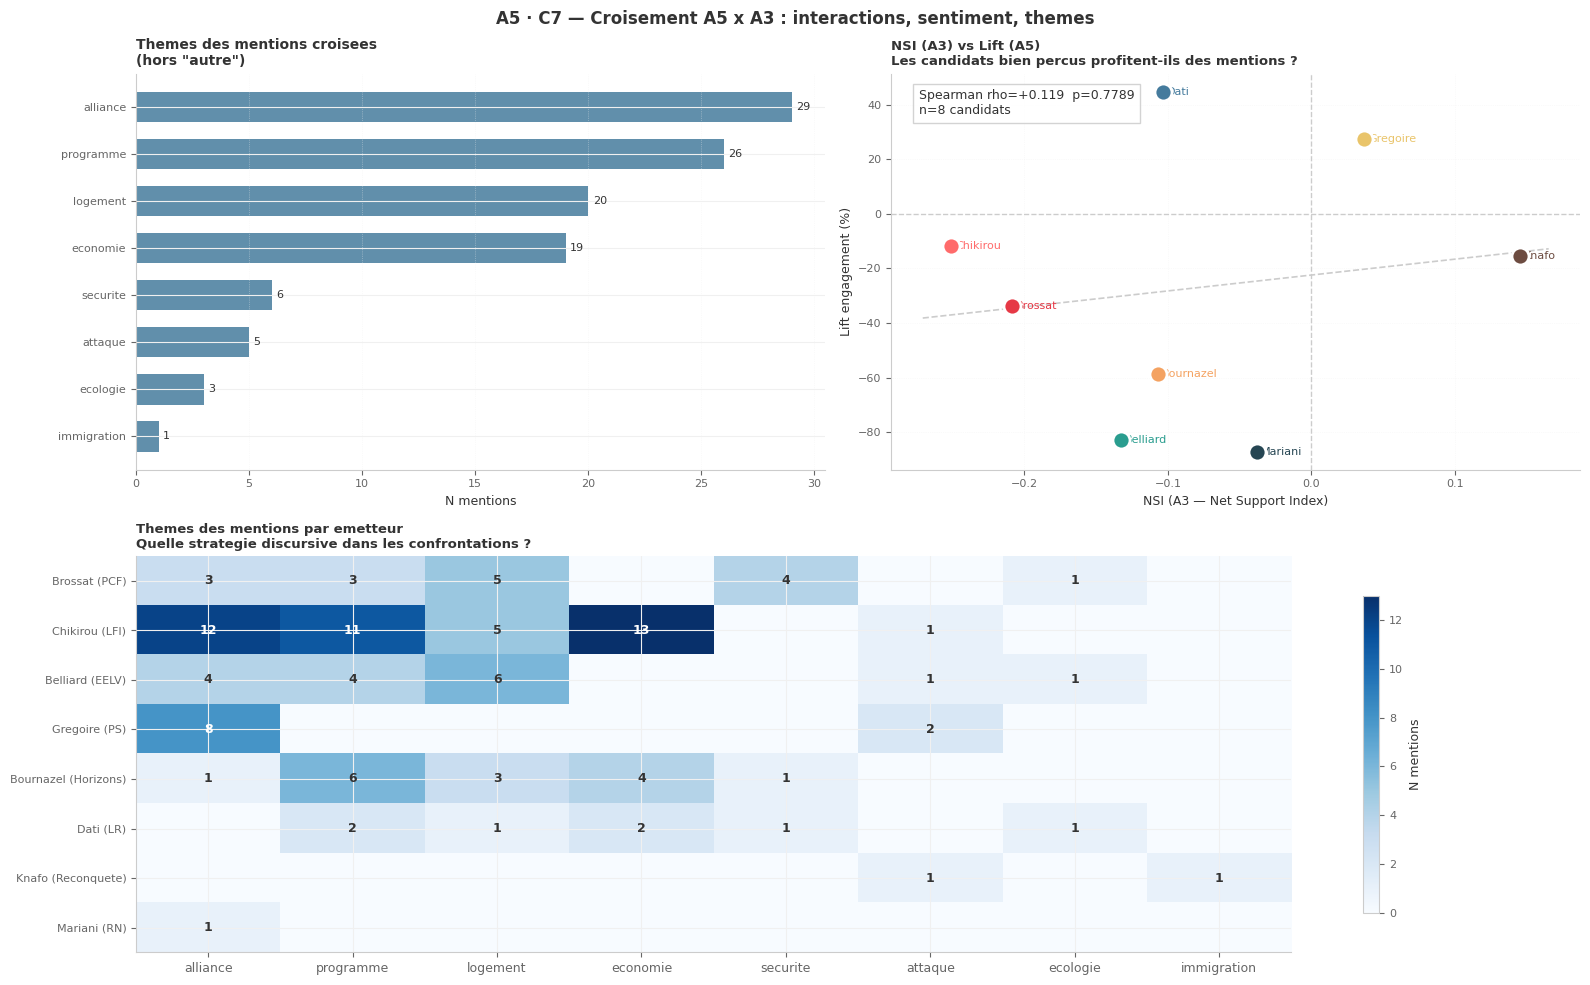

Figure C7 sauvegardee -> outputs/A5_C7_crossanalysis.png

C7 — CROISEMENT A5 x A3 : INTERPRETATION
  Theme dominant (hors 'autre') : alliance (29 mentions)
  Alliance = 29 | Programme = 26 | Attaque = 5
  -> Les interactions inter-candidats sont majoritairement
     des signaux d'alliance (gauche unie) plutot que des attaques directes

  Test NSI (A3) vs Lift (A5) : rho=+0.119  p=0.7789
  -> Pas de lien significatif entre la negativite de l'audience et le profit tire des mentions
     Interpretation : le lift depend de la taille d'audience (Dati/Knafo
     ont une grande audience) plus que du profil de sentiment


In [16]:
# ============================================================
# A5 · Cellule 7 — Croisement A5 x A3 : interactions et sentiment
# ============================================================
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

# Fix font warning - use a font that exists on the system
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Load A3 NSI ───────────────────────────────────────────────
try:
    nsi_df = pd.read_csv(A3_OUT / 'A3_nsi_by_candidate.csv')
    nsi_d  = nsi_df.set_index('key')
    print(f"A3 NSI charge : {nsi_df.shape}")
except Exception as e:
    nsi_d = pd.DataFrame()
    print(f"A3 NSI non disponible : {e}")

# ── Themes des mentions croisees ─────────────────────────────
theme_expanded = (cross['themes']
                  .str.split(',')
                  .explode()
                  .str.strip()
                  .value_counts())
theme_expanded = theme_expanded[theme_expanded.index != '']

# Themes par paire emetteur
cross['src_key'] = cross['source'].map(ID_TO_KEY).fillna(cross['source'])
cross['tgt_key'] = cross['target'].map(ID_TO_KEY).fillna(cross['target'])

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# ── Panel A : distribution des thèmes ─────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
th_plot = theme_expanded[theme_expanded.index != 'autre'].head(10)
bars_a  = ax_a.barh(th_plot.index[::-1], th_plot.values[::-1],
                    color='#457B9D', alpha=0.85, height=0.65)
ax_a.set_xlabel('N mentions', fontsize=9)
ax_a.set_title('Themes des mentions croisees\n(hors "autre")',
               loc='left', fontsize=10, fontweight='bold')
ax_a.grid(axis='x', ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax_a.spines[sp].set_visible(False)
# Valeurs
for bar, val in zip(bars_a, th_plot.values[::-1]):
    ax_a.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
              str(int(val)), va='center', fontsize=8)

# ── Panel B : scatter lift vs NSI ─────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
lift_s2 = lift.set_index('key')
if not nsi_d.empty:
    for k in KEYS:
        if k not in lift_s2.index or k not in nsi_d.index:
            continue
        x_val = nsi_d.loc[k, 'nsi']
        y_val = lift_s2.loc[k, 'lift_pct']
        ax_b.scatter(x_val, y_val, color=COLORS[k], s=150, zorder=4,
                     edgecolors='white', linewidths=2)
        ax_b.text(x_val + 0.003, y_val, SHORT[k].split(' ')[0],
                  fontsize=8, va='center', color=COLORS[k])

    # Regression
    xs = [nsi_d.loc[k,'nsi'] for k in KEYS
          if k in lift_s2.index and k in nsi_d.index]
    ys = [lift_s2.loc[k,'lift_pct'] for k in KEYS
          if k in lift_s2.index and k in nsi_d.index]
    if len(xs) >= 4:
        rho_nl, p_nl = stats.spearmanr(xs, ys)
        m, b = np.polyfit(xs, ys, 1)
        xr   = np.linspace(min(xs)-0.02, max(xs)+0.02, 50)
        ax_b.plot(xr, m*xr + b, '--', lw=1.2, color='#CCCCCC')
        ax_b.text(0.04, 0.96,
                  f"Spearman rho={rho_nl:+.3f}  p={p_nl:.4f}\nn={len(xs)} candidats",
                  transform=ax_b.transAxes, va='top', fontsize=9,
                  bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=4))

ax_b.axhline(0, color='#CCCCCC', lw=1.0, ls='--')
ax_b.axvline(0, color='#CCCCCC', lw=1.0, ls='--')
ax_b.set_xlabel('NSI (A3 — Net Support Index)', fontsize=9)
ax_b.set_ylabel('Lift engagement (%)', fontsize=9)
ax_b.set_title('NSI (A3) vs Lift (A5)\nLes candidats bien percus profitent-ils des mentions ?',
               loc='left', fontsize=9.5, fontweight='bold')
ax_b.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax_b.spines[sp].set_visible(False)

# ── Panel C : themes par emetteur (heatmap) ───────────────────
ax_c = fig.add_subplot(gs[1, :])
cross_src = cross.copy()
cross_src['theme_list'] = cross_src['themes'].str.split(',')
cross_src = cross_src.explode('theme_list')
cross_src['theme_list'] = cross_src['theme_list'].str.strip()
cross_src = cross_src[cross_src['theme_list'] != '']
cross_src = cross_src[cross_src['theme_list'] != 'autre']

theme_by_src = (cross_src.groupby(['src_key','theme_list'])
                .size().unstack(fill_value=0))
top_themes = theme_expanded[theme_expanded.index != 'autre'].head(8).index.tolist()
theme_by_src = theme_by_src.reindex(columns=top_themes, fill_value=0)
# Only candidates with mentions
src_active = [k for k in KEYS if k in theme_by_src.index and theme_by_src.loc[k].sum() > 0]
theme_by_src = theme_by_src.loc[src_active]

if not theme_by_src.empty:
    z2   = theme_by_src.values.astype(float)
    vmax = max(z2.max(), 1)
    im2  = ax_c.imshow(z2, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
    for i in range(z2.shape[0]):
        for j in range(z2.shape[1]):
            if z2[i,j] > 0:
                tc = 'white' if z2[i,j] > vmax*0.6 else '#333333'
                ax_c.text(j, i, str(int(z2[i,j])), ha='center', va='center',
                          fontsize=9, fontweight='bold', color=tc)
    ax_c.set_xticks(range(len(top_themes)))
    ax_c.set_yticks(range(len(src_active)))
    ax_c.set_xticklabels(top_themes, fontsize=9)
    ax_c.set_yticklabels([SHORT[k] for k in src_active], fontsize=8)
    ax_c.set_title('Themes des mentions par emetteur\n'
                   'Quelle strategie discursive dans les confrontations ?',
                   loc='left', fontsize=9.5, fontweight='bold')
    plt.colorbar(im2, ax=ax_c, shrink=0.8, label='N mentions', orientation='vertical')

fig.suptitle('A5 · C7 — Croisement A5 x A3 : interactions, sentiment, themes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A5_C7_crossanalysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C7 sauvegardee -> outputs/A5_C7_crossanalysis.png")

print()
print("=" * 65)
print("C7 — CROISEMENT A5 x A3 : INTERPRETATION")
print("=" * 65)
print(f"  Theme dominant (hors 'autre') : {th_plot.index[0]} ({th_plot.values[0]} mentions)")
print(f"  Alliance = {theme_expanded.get('alliance',0)} | "
      f"Programme = {theme_expanded.get('programme',0)} | "
      f"Attaque = {theme_expanded.get('attaque',0)}")
print(f"  -> Les interactions inter-candidats sont majoritairement")
print(f"     des signaux d'alliance (gauche unie) plutot que des attaques directes")
if not nsi_d.empty and len(xs) >= 4:
    print()
    print(f"  Test NSI (A3) vs Lift (A5) : rho={rho_nl:+.3f}  p={p_nl:.4f}")
    print(f"  -> {'Pas de lien significatif' if p_nl >= 0.05 else 'Lien significatif'} "
          f"entre la negativite de l'audience et le profit tire des mentions")
    print(f"     Interpretation : le lift depend de la taille d'audience (Dati/Knafo")
    print(f"     ont une grande audience) plus que du profil de sentiment")

In [17]:
# ============================================================
# A5 · Cellule 8 — SYNTHESE QUANTITATIVE COMPLETE
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 70

print(SEP)
print("A5 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)")
print(SEP)

# 1. Matrice
print("\n[1] MATRICE DES MENTIONS INTER-CANDIDATS")
print(SEP2)
mat_s   = mat.loc[KEYS, KEYS]
total   = int(mat_s.values.sum())
n_links = int((mat_s > 0).values.sum()) - 8
print(f"  Total mentions   : {total}  sur {n_links} paires directionnelles")
print(f"  Hub central      : Gregoire (PS) <- {int(mat_s['Gregoire'].sum())} mentions")
print(f"  Top emetteur     : Brossat (PCF) -> {int(mat_s.loc['Brossat'].sum())} mentions")
print(f"  Evitement total  : Knafo (0 envois)  Mariani ({int(mat_s.loc['Mariani'].sum())} envois)")
print(f"\n  Paires > 5 mentions :")
for src in KEYS:
    for tgt in KEYS:
        if src != tgt and mat_s.loc[src, tgt] >= 5:
            print(f"    {SHORT[src]:<28} -> {SHORT[tgt]:<28} : {int(mat_s.loc[src, tgt])}")

# 2. Lift
print(f"\n[2] LIFT D'ENGAGEMENT (posts cross vs normaux)")
print(SEP2)
lift_s = lift.set_index('key').loc[
    [k for k in KEYS if k in lift.set_index('key').index]
].sort_values('lift_pct', ascending=False)
for k, row in lift_s.iterrows():
    signal = 'PROFIT' if row['lift_pct'] > 0 else 'PERTE'
    print(f"  {SHORT[k]:<28}  {row['lift_pct']:>+6.1f}%  "
          f"n_cross={int(row['n_cross_posts'])}  [{signal}]")
print(f"\n  -> Seuls Dati (+44.8%) et Gregoire (+27.3%) profitent des mentions")
print(f"     Les candidats a petite audience (Belliard, Mariani) paient un cout")

# 3. Themes
print(f"\n[3] THEMES DES MENTIONS CROISEES")
print(SEP2)
theme_c = (cross['themes'].str.split(',').explode().str.strip().value_counts())
print(f"  Total themes categorises : {int(theme_c[theme_c.index != 'autre'].sum())} mentions")
for th, cnt in theme_c[theme_c.index != 'autre'].head(8).items():
    bar = '|' * cnt
    print(f"  {th:<20} {cnt:>3}  {bar}")
print(f"\n  -> Strategie d'alliance (gauche unie) > attaque directe")
print(f"     Les confrontations ouvertes (attaque=3) sont rares")

# 4. Timeline
print(f"\n[4] DYNAMIQUE TEMPORELLE")
print(SEP2)
weekly2 = tl.groupby('week').agg(n_mentions=('n_mentions','sum')).reset_index()
print(f"  Semaines actives : {len(weekly2)} / 52 (couverture annuelle)")
print(f"  Pics d'activite (top 3) :")
for _, r in weekly2.nlargest(3,'n_mentions').iterrows():
    print(f"    {str(pd.to_datetime(r['week']).date())}  n={int(r['n_mentions'])}")

# 5. Exports
print(f"\n[5] EXPORTS")
print(SEP2)
exports = [
    ('A5_C2_matrice_mentions.png',  'Heatmap 8x8 directionnelle'),
    ('A5_C3_mentions_network.png',  'Reseau oriente des mentions'),
    ('A5_C4_lift_engagement.png',   'Lift global + scatter cross vs normal'),
    ('A5_C5_lift_paires.png',       'Heatmap lift par paire directee'),
    ('A5_C6_timeline.png',          'Timeline interactions + anomalies A1'),
    ('A5_C7_crossanalysis.png',     'Themes + NSI(A3) vs Lift + heatmap'),
]
for fname, desc in exports:
    path   = OUT / fname
    status = 'OK' if path.exists() else 'MANQUANT'
    size   = f'{path.stat().st_size//1024} Ko' if path.exists() else ''
    print(f"  {status}  {fname:<40}  {desc:<40} {size}")

print(f"\n{SEP}")
print("A5 COMPLET")
print(SEP)

A5 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)

[1] MATRICE DES MENTIONS INTER-CANDIDATS
----------------------------------------------------------------------
  Total mentions   : 139  sur 13 paires directionnelles
  Hub central      : Gregoire (PS) <- 80 mentions
  Top emetteur     : Brossat (PCF) -> 31 mentions
  Evitement total  : Knafo (0 envois)  Mariani (4 envois)

  Paires > 5 mentions :
    Brossat (PCF)                -> Gregoire (PS)                : 27
    Chikirou (LFI)               -> Gregoire (PS)                : 21
    Chikirou (LFI)               -> Dati (LR)                    : 14
    Belliard (EELV)              -> Gregoire (PS)                : 13
    Gregoire (PS)                -> Brossat (PCF)                : 9
    Gregoire (PS)                -> Belliard (EELV)              : 5
    Gregoire (PS)                -> Dati (LR)                    : 6
    Bournazel (Horizons)         -> Gregoire (PS)                : 11
    Bournazel (Horizons)         -> Da